# Notebook 0B — Zone Health Composite Index

**Real Estate Intelligence Platform (REIP)**

Reproducimos, con código y gráficos, el Zone Health Composite Index calculado en Feature 1.4:
un índice compuesto de calidad de zona sobre las 9 zonas del scope, construido a partir de 4
dimensiones cuantitativas (seguridad, transporte, amenidades, walkability). Es un eje evaluativo
independiente — nunca se cruza como feature de los modelos de precio de M2 (colinealidad perfecta
con corregimiento, ya variable de agrupación en KNN/RF), y no depende del catálogo residencial que
consolidamos en Notebook 0.

En vez de reimplementar las fórmulas, importamos y ejecutamos directamente los módulos de
producción de `pipeline/zone_health/`, ya cerrados y con suite de tests en verde — esto reproduce
los resultados con el mismo código que los generó, en vez de arriesgar una divergencia por
reimplementación paralela.


## Verificación de entorno y rutas

Confirmamos contra el estado real del repositorio, antes de escribir cualquier celda de análisis:

**Fuente de verdad de Feature 1.4:** `Context-MD/Feature_1_4_Zone_Health_Composite_Index_Documentacion_Granular.md`
— documentación granular por subtarea (1.4.1 a 1.4.7), más detallada que el resumen de `CLAUDE.md`.

**Scripts de producción que importamos** (`pipeline/zone_health/`): `normalizacion_seguridad.py`,
`normalizacion_transporte.py`, `normalizacion_amenidades.py`, `normalizacion_walkability.py`,
`composite_zone_health.py`, `cruce_espacial_corregimiento.py`. Cada uno resuelve su propia ruta de
entrada/salida de forma relativa a su propio archivo (`Path(__file__).resolve()...`), por lo que
funcionan igual sin importar desde dónde se ejecute este notebook.

**Fuentes externas que consumen esos scripts** (`pipeline/data/external/`): `seguridad/`,
`gtfs/`, `metro/`, `amenidades/`, `corregimientos/`, `socioeconomico/` — confirmamos que las 6
carpetas existen con los archivos que cada script espera.

**Salidas ya calculadas** (`pipeline/data/processed/`): `zone_health_seguridad_1_4_1.json`,
`zone_health_transporte_1_4_2.json`, `zone_health_amenidades_1_4_3.json`,
`zone_health_walkability_1_4_4.json`, `zone_health_composite_1_4_6.json` — estos 5 archivos ya
existen; los recalculamos aquí desde las fuentes crudas como verificación independiente, no porque
falten.

**Entorno de ejecución:** `notebooks/venv` (kernel `reip-notebooks`). A las librerías ya
instaladas para Notebook 0 agregamos `shapely`, requerida por los scripts de cruce espacial que
importamos en este notebook.

**Alcance de las 9 zonas:** 5 zonas reales con extracción propia (Bella Vista, San Francisco,
Parque Lefevre, Betania, Pedregal); El Cangrejo, Marbella y Obarrio heredan el composite y
desglose completo de Bella Vista (copia literal, no promedio); Costa del Este no recibe score
compuesto (4 de 5 dimensiones sin insumo propio).


In [1]:
import sys
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

REPO_ROOT = Path("..").resolve()
assert (REPO_ROOT / "pipeline" / "zone_health").exists(), f"No existe {REPO_ROOT / 'pipeline' / 'zone_health'}"
sys.path.insert(0, str(REPO_ROOT))

from pipeline.zone_health import normalizacion_seguridad as ns
from pipeline.zone_health import normalizacion_transporte as nt
from pipeline.zone_health import normalizacion_amenidades as na
from pipeline.zone_health import normalizacion_walkability as nw
from pipeline.zone_health import composite_zone_health as cz

PROCESSED_DIR = REPO_ROOT / "pipeline" / "data" / "processed"
ZONAS_REALES = ns.ZONAS_REALES

# Trazabilidad: commit de pipeline/zone_health/ en el momento en que se importaron
# estos modulos en este notebook. Si los archivos cambian mas adelante, los
# numeros de este notebook quedan atados a esta version exacta, no a la version
# vigente al momento de leerlo.
COMMIT_ZONE_HEALTH = "8df51765cecb923d16dbf520a4e296d69e325bd4"  # 2026-07-13 11:16:37 -0500

print("Módulos importados. Zonas reales:", ZONAS_REALES)
print("Commit de pipeline/zone_health/ en el momento de esta ejecución:", COMMIT_ZONE_HEALTH)


Módulos importados. Zonas reales: ['Bella Vista', 'Betania', 'Parque Lefevre', 'Pedregal', 'San Francisco']
Commit de pipeline/zone_health/ en el momento de esta ejecución: 8df51765cecb923d16dbf520a4e296d69e325bd4


**Verificación de que estos módulos no dependen de infraestructura externa:** revisamos los
imports de los 6 archivos que importamos (`normalizacion_seguridad.py`, `normalizacion_transporte.py`,
`normalizacion_amenidades.py`, `normalizacion_walkability.py`, `composite_zone_health.py`,
`cruce_espacial_corregimiento.py`) — ninguno importa un cliente de Supabase/Postgres
(`psycopg`, `sqlalchemy`) ni hace llamadas de red (`requests`, `urlopen`). Los únicos imports son
de librería estándar (`json`, `pathlib`, `math`, `sys`) y `shapely.geometry` (cálculo geométrico
puro, sin I/O de red). Todo el input de estos módulos son los archivos locales de
`pipeline/data/external/` y `pipeline/data/processed/` ya verificados arriba — consistente con que
Feature 1.5 (carga a Supabase) sigue sin iniciarse.


## 1. Seguridad (Feature 1.4.1, peso 0.352941176 del composite)

Normalizamos `tasa_por_100k` (homicidios SIEC 2023) a un score en [0,1] vía min-max invertido —
tasa alta de homicidios debe traducirse en score de seguridad bajo, así que sin invertir la zona
más peligrosa saldría con el score más alto. Cubre únicamente las 5 zonas con corregimiento
administrativo real; El Cangrejo, Marbella, Obarrio y Costa del Este no tienen `tasa_por_100k`
propia.


In [2]:
tasas_seguridad = ns._cargar_tasas_desde_jsonl(ns.RUTA_ENTRADA)
scores_seguridad = ns.normalizar_seguridad(tasas_seguridad)

df_seguridad = pd.DataFrame({
    "corregimiento": list(tasas_seguridad.keys()),
    "tasa_por_100k": list(tasas_seguridad.values()),
}).assign(score_seguridad=lambda d: d["corregimiento"].map(scores_seguridad))
df_seguridad = df_seguridad.sort_values("tasa_por_100k")
df_seguridad


,corregimiento,tasa_por_100k,score_seguridad
4,San Francisco,3.26,1.000000
1,Betania,4.74,0.916620
0,Bella Vista,14.83,0.348169
3,Pedregal,15.60,0.304789
2,Parque Lefevre,21.01,0.000000


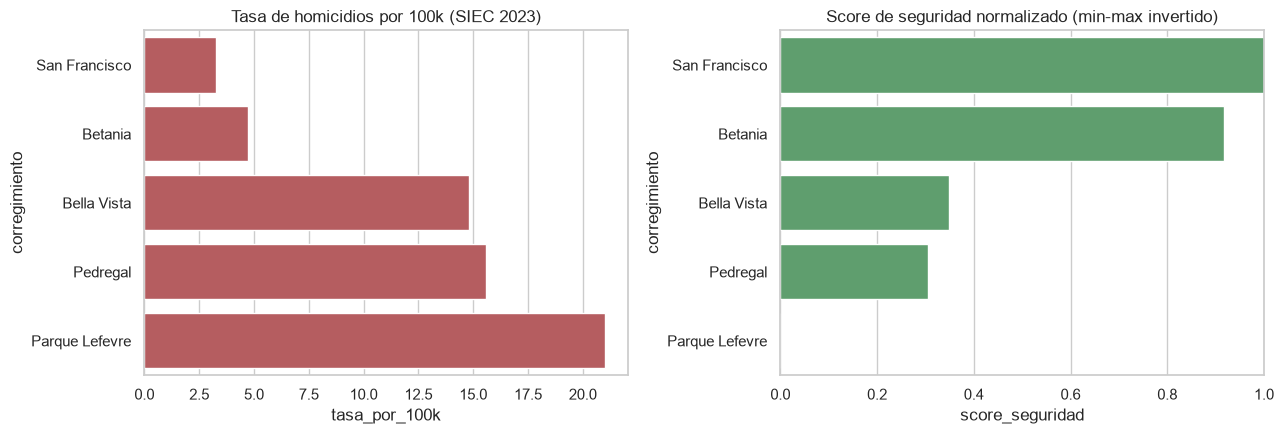

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.barplot(data=df_seguridad, x="tasa_por_100k", y="corregimiento", ax=axes[0], color="#C44E52")
axes[0].set_title("Tasa de homicidios por 100k (SIEC 2023)")

sns.barplot(data=df_seguridad, x="score_seguridad", y="corregimiento", ax=axes[1], color="#55A868")
axes[1].set_title("Score de seguridad normalizado (min-max invertido)")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()


Confirmamos la inversión: San Francisco, con la tasa más baja (3.26), obtiene el score más
alto (1.0); Parque Lefevre, con la tasa más alta (21.01), obtiene el score más bajo (0.0).
**Limitación que documentamos explícitamente, no ocultamos:** con n=5, el método min-max es muy
sensible a valores extremos — Parque Lefevre (21.01) está considerablemente por encima del resto
del rango (3.26-15.60 en las otras 4 zonas), lo que empuja su score a 0 de forma más drástica que
si la muestra fuera más grande.


## 2. Transporte (Feature 1.4.2, peso 0.235294118)

Calculamos densidad de puntos de transporte (paradas GTFS de MiBus + estaciones de Metro,
contadas sin ponderar por tipo) por km² de cada zona, normalizada sin inversión — más densidad es
mejor.


In [4]:
conteos_transporte = nt._contar_puntos_transporte(nt.RUTA_METRO, nt.RUTA_GTFS)
superficies = nt._cargar_superficies_desde_jsonl(nt.RUTA_SUPERFICIE)
densidades_transporte = {z: conteos_transporte[z] / superficies[z] for z in ZONAS_REALES}
scores_transporte = nt.normalizar_transporte(densidades_transporte)

df_transporte = pd.DataFrame({
    "corregimiento": ZONAS_REALES,
    "conteo_puntos": [conteos_transporte[z] for z in ZONAS_REALES],
    "superficie_km2": [superficies[z] for z in ZONAS_REALES],
    "densidad_km2": [densidades_transporte[z] for z in ZONAS_REALES],
    "score_transporte": [scores_transporte[z] for z in ZONAS_REALES],
}).sort_values("densidad_km2", ascending=False)
df_transporte


,corregimiento,conteo_puntos,superficie_km2,densidad_km2,score_transporte
0,Bella Vista,46,4.581,10.041476,1.000000
1,Betania,62,8.235,7.528840,0.696880
4,San Francisco,49,6.655,7.362885,0.676859
2,Parque Lefevre,44,7.231,6.084912,0.522687
3,Pedregal,50,28.535,1.752234,0.000000


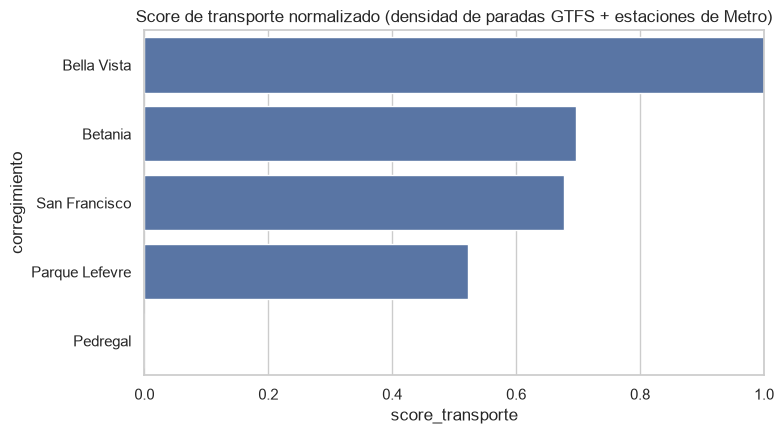

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=df_transporte, x="score_transporte", y="corregimiento", ax=ax, color="#4C72B0")
ax.set_title("Score de transporte normalizado (densidad de paradas GTFS + estaciones de Metro)")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()


**Limitación que documentamos explícitamente:** el conteo suma paradas de bus y estaciones de
metro con el mismo peso — una estación de metro mueve órdenes de magnitud más pasajeros que una
parada de bus individual, pero ambas cuentan como "1 punto" aquí. No se corrigió con un peso
arbitrario por falta de sustento para elegir un factor específico; queda como riesgo aceptado, no
como error de cómputo.


## 3. Amenidades (Feature 1.4.3, peso 0.235294118)

Calculamos un conteo ponderado por categoría (supermercado, parque, salud, colegio, farmacia — con
pesos derivados de la Encuesta de Requerimientos) y lo normalizamos sin inversión.


In [6]:
conteos_categoria = na._cargar_conteos_por_zona()
conteos_ponderados = {z: na.calcular_conteo_ponderado(conteos_categoria[z]) for z in ZONAS_REALES}
scores_amenidades = na.normalizar_amenidades(conteos_ponderados)

df_pesos = pd.DataFrame(list(na.PESOS.items()), columns=["categoria", "peso"]).sort_values("peso", ascending=False)
df_pesos


,categoria,peso
0,supermercado,0.3137
1,parque,0.2549
2,salud,0.2353
3,colegio,0.0980
4,farmacia,0.0980


In [7]:
df_amenidades_cat = pd.DataFrame(conteos_categoria).T[na.CATEGORIAS]
df_amenidades_cat["conteo_ponderado"] = [conteos_ponderados[z] for z in df_amenidades_cat.index]
df_amenidades_cat["score_amenidades"] = [scores_amenidades[z] for z in df_amenidades_cat.index]
df_amenidades_cat = df_amenidades_cat.sort_values("conteo_ponderado", ascending=False)
df_amenidades_cat


,supermercado,farmacia,salud,parque,colegio,conteo_ponderado,score_amenidades
Betania,12,19,20,29,24,20.0765,1.000000
Parque Lefevre,12,5,5,19,12,11.4500,0.513282
San Francisco,5,8,5,3,9,5.1757,0.159277
Bella Vista,2,3,1,3,6,2.5094,0.008841
Pedregal,2,1,2,3,4,2.3527,0.000000


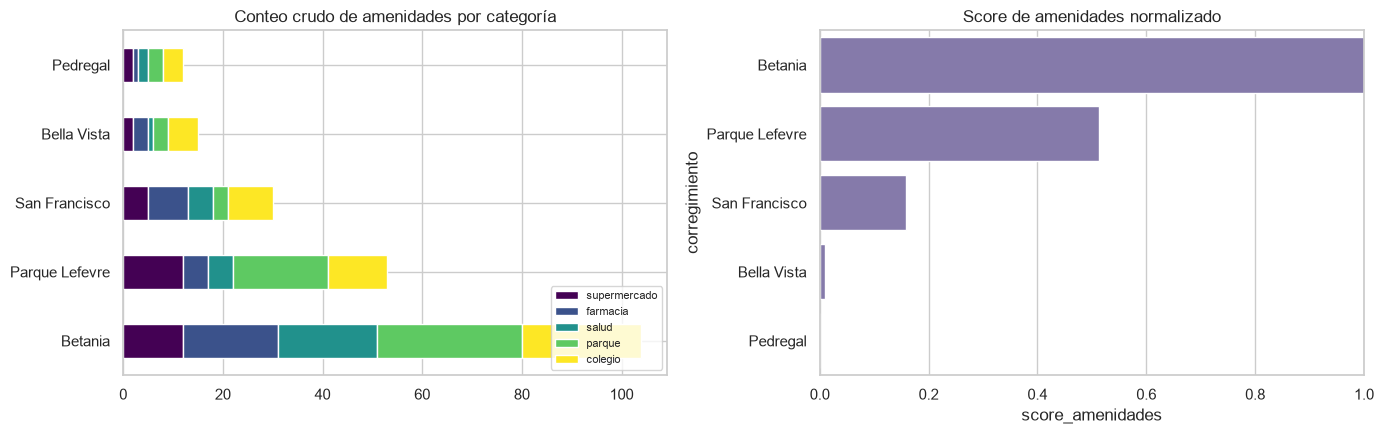

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

df_amenidades_cat[na.CATEGORIAS].loc[df_amenidades_cat.index].plot(
    kind="barh", stacked=True, ax=axes[0], colormap="viridis"
)
axes[0].set_title("Conteo crudo de amenidades por categoría")
axes[0].legend(loc="lower right", fontsize=8)

sns.barplot(data=df_amenidades_cat.reset_index().rename(columns={"index": "corregimiento"}),
            x="score_amenidades", y="corregimiento", ax=axes[1], color="#8172B2")
axes[1].set_title("Score de amenidades normalizado")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()


**Limitación que documentamos explícitamente, aceptada al cierre de Feature 1.4 en vez de
re-extraer:** Bella Vista y San Francisco tienen sub-cobertura conocida en sus archivos de Google
Places (por ejemplo, Riba Smith — supermercado grande y reconocido — está confirmado ausente del
archivo de Bella Vista), mientras que Betania recibió una re-extracción completa con bounding box
corregido. El ranking relativo entre Bella Vista y Parque Lefevre podría cambiar si se completara
esa cobertura — el margen actual entre ambas no es amplio. Retomamos esto en la sección 7.


## 4. Walkability (Feature 1.4.4, peso 0.176470588)

Calculamos, para cada zona, la distancia promedio desde el centroide de su polígono a la
amenidad más cercana de 3 categorías clave (supermercado, parque, metro — confirmadas por la
Encuesta de Requerimientos), normalizada con inversión: distancia alta implica score bajo. No
incluye un componente de densidad de red vial peatonal — verificamos que no existe ningún dato de
red vial en el repositorio.


In [9]:
centroides = nw._cargar_centroides()
puntos_supermercado, puntos_parque = nw._cargar_puntos_supermercado_y_parque()
puntos_metro = nw._cargar_puntos_metro()

distancias_zona = {
    z: nw.calcular_distancias_zona(centroides[z], puntos_supermercado, puntos_parque, puntos_metro)
    for z in ZONAS_REALES
}
promedios = {z: distancias_zona[z]["distancia_promedio_m"] for z in ZONAS_REALES}
scores_walkability = nw.normalizar_walkability(promedios)

df_walkability = pd.DataFrame(distancias_zona).T
df_walkability["score_walkability"] = [scores_walkability[z] for z in df_walkability.index]
df_walkability = df_walkability.sort_values("distancia_promedio_m")
df_walkability


,distancia_supermercado_m,distancia_parque_m,distancia_metro_m,distancia_promedio_m,score_walkability
Bella Vista,31.213275,548.005774,332.972786,304.063945,1.000000
Betania,292.176144,391.761744,1067.406345,583.781411,0.881205
San Francisco,101.885423,812.138332,1492.193170,802.072308,0.788498
Parque Lefevre,146.045647,602.404215,1915.633725,888.027862,0.751993
Pedregal,1373.425780,2413.714954,4188.918445,2658.686393,0.000000


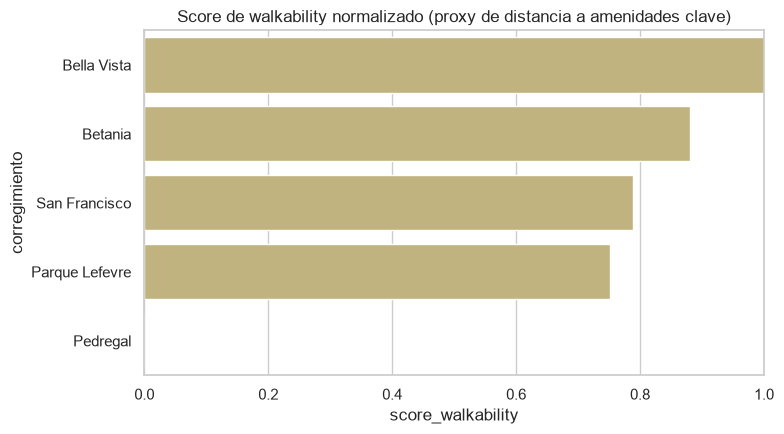

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=df_walkability.reset_index().rename(columns={"index": "corregimiento"}),
            x="score_walkability", y="corregimiento", ax=ax, color="#CCB974")
ax.set_title("Score de walkability normalizado (proxy de distancia a amenidades clave)")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()


## 5. Socioeconómico (Feature 1.4.5) — dimensión eliminada del composite

La dimensión socioeconómica original (WBS: población, vivienda, alfabetización, composición de
hogares) se redujo a solo población y densidad — el Censo 2023 no tiene alfabetización ni
composición de hogares a nivel de corregimiento. Densidad poblacional no es un proxy defendible de
nivel socioeconómico sin una dirección normativa justificable: más densidad puede leerse como mayor
centralidad urbana deseable o como hacinamiento, ambas lecturas igualmente plausibles con la
evidencia disponible. Por eso eliminamos la dimensión completa del composite, en vez de forzar una
dirección arbitraria — su peso (0.15) se redistribuyó proporcionalmente entre las 4 dimensiones
restantes (sección 6). Los datos de población/densidad siguen disponibles como dato descriptivo de
zona, no como insumo del score compuesto.


In [11]:
with open(REPO_ROOT / "pipeline" / "data" / "external" / "socioeconomico" / "inec_poblacion_densidad_2023.jsonl", encoding="utf-8") as f:
    registros_socioeconomico = [json.loads(linea) for linea in f]

df_socioeconomico = pd.DataFrame(registros_socioeconomico)[
    ["corregimiento", "poblacion_2023", "superficie_km2", "densidad_hab_km2"]
].sort_values("densidad_hab_km2", ascending=False)
df_socioeconomico


,corregimiento,poblacion_2023,superficie_km2,densidad_hab_km2
4,San Francisco,61290.0,6.655,9210.1
0,Bella Vista,33710.0,4.581,7358.4
2,Parque Lefevre,42832.0,7.231,5923.7
1,Betania,42199.0,8.235,5124.5
3,Pedregal,57682.0,28.535,2021.5
5,El Cangrejo,NaN,NaN,NaN
6,Marbella,NaN,NaN,NaN
7,Obarrio,NaN,NaN,NaN
8,Costa del Este,NaN,NaN,NaN


## 6. Composite (Feature 1.4.6) — fórmula ponderada final y herencia

Los pesos originales (5 dimensiones, seguridad 0.30 / transporte 0.20 / amenidades 0.20 /
walkability 0.15 / socioeconómico 0.15) se redistribuyen proporcionalmente tras eliminar
socioeconómico, dividiendo cada peso restante entre 0.85 — no se reparte el 0.15 sobrante en
partes iguales sin justificación, sino que se preserva el orden relativo de prioridad ya trazado.


In [12]:
df_pesos_composite = pd.DataFrame(list(cz.PESOS.items()), columns=["dimension", "peso"])
df_pesos_composite["suma"] = df_pesos_composite["peso"].sum()
assert abs(df_pesos_composite["peso"].sum() - 1.0) < 1e-9
df_pesos_composite


,dimension,peso,suma
0,seguridad,0.352941,1.0
1,transporte,0.235294,1.0
2,amenidades,0.235294,1.0
3,walkability,0.176471,1.0


In [13]:
desgloses_zonas_reales = {
    z: {
        "seguridad": scores_seguridad[z],
        "transporte": scores_transporte[z],
        "amenidades": scores_amenidades[z],
        "walkability": scores_walkability[z],
    }
    for z in ZONAS_REALES
}
zonas_composite = cz.construir_composite_zone_health(desgloses_zonas_reales)

filas = []
for zona, registro in zonas_composite.items():
    fila = {"corregimiento": zona, "composite": registro["composite"],
            "estado": registro["estado_zone_health"]}
    if registro.get("hereda_de"):
        fila["hereda_de"] = registro["hereda_de"]
    if registro.get("estado_visualizacion"):
        fila["estado_visualizacion"] = registro["estado_visualizacion"]
    filas.append(fila)

df_composite = pd.DataFrame(filas).sort_values("composite", ascending=False, na_position="last")
df_composite


,corregimiento,composite,estado,estado_visualizacion,hereda_de
1,Betania,0.878285,calculado,NaN,NaN
4,San Francisco,0.688826,calculado,NaN,NaN
0,Bella Vista,0.536728,calculado,NaN,NaN
5,El Cangrejo,0.536728,calculado,NaN,Bella Vista
6,Marbella,0.536728,calculado,NaN,Bella Vista
7,Obarrio,0.536728,calculado,NaN,Bella Vista
2,Parque Lefevre,0.376462,calculado,NaN,NaN
3,Pedregal,0.107572,calculado,no_visualizado,NaN
8,Costa del Este,NaN,sin_score_datos_insuficientes,NaN,NaN


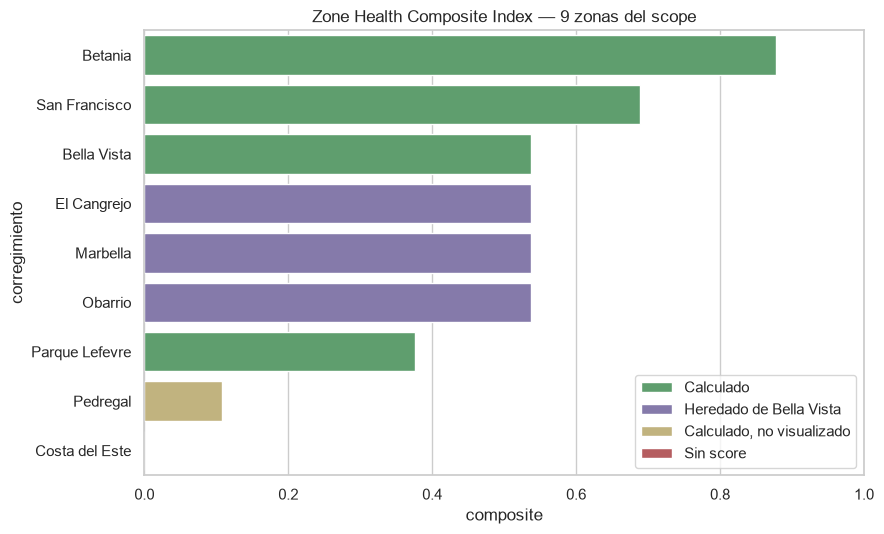

In [14]:
def categoria_barra(row):
    if pd.isna(row["composite"]):
        return "Sin score"
    if row.get("estado_visualizacion") == "no_visualizado":
        return "Calculado, no visualizado"
    if "hereda_de" in row and pd.notna(row.get("hereda_de")):
        return "Heredado de Bella Vista"
    return "Calculado"

df_composite["categoria"] = df_composite.apply(categoria_barra, axis=1)
colores_categoria = {
    "Calculado": "#55A868",
    "Heredado de Bella Vista": "#8172B2",
    "Calculado, no visualizado": "#CCB974",
    "Sin score": "#C44E52",
}

df_grafico = df_composite.copy()
df_grafico["composite_graf"] = df_grafico["composite"].fillna(0)

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(data=df_grafico, x="composite_graf", y="corregimiento", hue="categoria",
            palette=colores_categoria, dodge=False, ax=ax)
ax.set_xlim(0, 1)
ax.set_xlabel("composite")
ax.set_title("Zone Health Composite Index — 9 zonas del scope")
ax.legend(title="", loc="lower right")
plt.tight_layout()
plt.show()


Confirmamos las reglas de herencia: El Cangrejo, Marbella y Obarrio reciben una copia literal
del composite y desglose completo de Bella Vista — no un promedio ni un ajuste. Costa del Este
queda sin composite ni desglose (`estado_zone_health = "sin_score_datos_insuficientes"`): 4 de sus
5 dimensiones originales no tenían insumo propio, y la herencia planeada de Juan Díaz nunca se
concretó porque esa zona está fuera del scope de 9 zonas. Pedregal sí entra a la fórmula
determinística (se calcula), pero queda marcado `estado_visualizacion = "no_visualizado"` por
amenidades débiles frente al resto del scope (12 POIs vs. 32-52 promedio del resto de zonas) — la
exclusión es de presentación, no de cómputo. Esta decisión de no-visualización está citada
explícitamente en la fuente, no es una inferencia nuestra por el volumen bajo de Pedregal (n=3):
`Context-MD/Feature_1_4_Zone_Health_Composite_Index_Documentacion_Granular.md` (§0, tabla de
composite final; §7, Feature 1.4.6, reglas de herencia) y, en el propio código de
`composite_zone_health.py`, la constante `MOTIVO_NO_VISUALIZADO` cita como fuente original
"Acta 1.3.7 §6".


## 7. Revisión cualitativa (Feature 1.4.7)

Confrontamos el ranking resultante contra la intuición de mercado esperada para cada zona.


In [15]:
revision_cualitativa = pd.DataFrame([
    {"corregimiento": "San Francisco",  "coincide_intuicion": True,  "nota": "Zona premium reconocida"},
    {"corregimiento": "Pedregal",       "coincide_intuicion": True,  "nota": "Consistente con el ejemplo textual de referencia"},
    {"corregimiento": "Parque Lefevre", "coincide_intuicion": True,  "nota": "Menor perfil relativo dentro del scope"},
    {"corregimiento": "Betania",        "coincide_intuicion": False, "nota": "Score más alto de las 5 zonas reales, contraintuitivo"},
    {"corregimiento": "Bella Vista",    "coincide_intuicion": False, "nota": "Más bajo de lo esperado para una zona financiera/comercial central"},
])
revision_cualitativa


,corregimiento,coincide_intuicion,nota
0,San Francisco,True,Zona premium reconocida
1,Pedregal,True,Consistente con el ejemplo textual de referencia
2,Parque Lefevre,True,Menor perfil relativo dentro del scope
3,Betania,False,"Score más alto de las 5 zonas reales, contrain..."
4,Bella Vista,False,Más bajo de lo esperado para una zona financie...


Identificamos una única causa raíz detrás de ambas anomalías: la profundidad de auditoría del
archivo de amenidades no fue uniforme entre zonas. Betania recibió una re-extracción completa
(bounding box corregido, 104 features) durante el cierre de Feature 1.4.3; Bella Vista y San
Francisco quedaron con sub-cobertura conocida y no corregida (sección 3). El ranking actual refleja,
en parte, qué tan exhaustivamente se auditó cada fuente de amenidades — no únicamente qué tan buena
es cada zona real. **Dejamos esto explícito aquí, en vez de presentar el ranking como un resultado
limpio,** porque es la interpretación correcta de una limitación de cobertura de datos, no una
propiedad real de las zonas.


## 8. Exportación

In [16]:
OUTPUT_PATH = PROCESSED_DIR / "zone_health_resumen_6_2_2.csv"
df_composite.drop(columns=["categoria"], errors="ignore").to_csv(OUTPUT_PATH, index=False)
print(f"Exportado: {OUTPUT_PATH.resolve()}")
df_composite.drop(columns=["categoria"], errors="ignore")


Exportado: /Users/heliocastillo/Proyecto-REIP/Real-Estate-Intelligence-Platform/pipeline/data/processed/zone_health_resumen_6_2_2.csv


,corregimiento,composite,estado,estado_visualizacion,hereda_de
1,Betania,0.878285,calculado,NaN,NaN
4,San Francisco,0.688826,calculado,NaN,NaN
0,Bella Vista,0.536728,calculado,NaN,NaN
5,El Cangrejo,0.536728,calculado,NaN,Bella Vista
6,Marbella,0.536728,calculado,NaN,Bella Vista
7,Obarrio,0.536728,calculado,NaN,Bella Vista
2,Parque Lefevre,0.376462,calculado,NaN,NaN
3,Pedregal,0.107572,calculado,no_visualizado,NaN
8,Costa del Este,NaN,sin_score_datos_insuficientes,NaN,NaN


## 9. Conclusiones

Reproducimos, con los mismos módulos de producción que los generaron, los 4 scores de dimensión y
el composite final de Feature 1.4 para las 9 zonas del scope, obteniendo exactamente los valores ya
documentados: Betania (0.8783) por encima de San Francisco (0.6888) y Bella Vista (0.5367), con
Parque Lefevre (0.3765) y Pedregal (0.1076, calculado pero no visualizado) por debajo. Confirmamos
la redistribución proporcional de pesos tras eliminar la dimensión socioeconómica, la herencia
literal de El Cangrejo/Marbella/Obarrio desde Bella Vista, y la ausencia de score para Costa del
Este por insuficiencia estructural de datos.

Documentamos, con la misma transparencia que exige la sección 7, que el ranking entre Betania y
Bella Vista/San Francisco refleja en parte una diferencia real de profundidad de auditoría de
amenidades entre zonas, no únicamente una diferencia real de calidad de zona — limitación ya
aceptada al cierre de Feature 1.4, que reproducimos aquí explícitamente en vez de omitirla.

Exportamos una tabla resumen (`pipeline/data/processed/zone_health_resumen_6_2_2.csv`) con el
composite y estado de cada zona, como referencia rápida para consumo descriptivo. El Zone Health
Composite Index permanece como eje evaluativo independiente: no se cruza como feature de los
modelos de precio de M2, dado que ya es función determinística de corregimiento — la misma
variable de agrupación que KNN y Random Forest usan directamente.
